In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plot_dsa_tools as tools
import importlib

# setup plotting
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["axes.labelsize"] = 25  
plt.rcParams["xtick.labelsize"] = 20  
plt.rcParams["ytick.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 18  
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"
%config InlineBackend.figure_format = 'retina'
plt.rcParams['axes.xmargin'] = 0

In [37]:
# calculate bands for correlations

Q0 = '0p5'
xi = '1p5'
rs = '40'
reps = '300'

fold = 'data/largeNcq'
zfiles = [
    f'{fold}/dsa_p_rs40_Q00p5_xi1p5_pn_300reps_largeNcq_pp_constrained.npy',
    f'{fold}/dsa_pt0p1z0p2_rs{rs}_Q0{Q0}_xi{xi}_pn_{reps}reps_largeNcq_sr_constrained.npy'
         ]
# zfiles = [f'{fold}/dsa_pt0p1z0p2_rs{rs}_Q0{Q0}_xi{xi}_pn_{reps}reps_largeNcq_sr_constrained.npy']
zdata = tools.get_data(zfiles)


files = [
        f'{fold}/dsa_p_rs40_Q00p5_xi1p5_pn_300reps_largeNcq_dis.npy', 
        f'{fold}/dsa_p_rs40_Q00p5_xi1p5_pn_300reps_largeNcq_pp.npy',
        f'{fold}/dsa_p_rs40_Q00p5_xi1p5_pn_300reps_largeNcq_pp_constrained.npy'
         ]
data = tools.get_data(files)

tfiles = [f'{fold}/dsa_p_rs40_Q00p5_xi1p5_pn_300reps_largeNcq_pp_constrained.npy',
          f'{fold}/dsa_pt0p1_rs40_Q00p5_xi1p5_pn_300reps_largeNcq_pp_constrained.npy'
          ]
tdata = tools.get_data(tfiles)



# file = f'{fold}/dsa_pt0p1_rs{rs}_Q0{Q0}_xi{xi}_pn_{reps}reps_largeNcq.npy'
# data = tools.get_data([file])

# mixfiles = [f'{fold}/dsa_pt0p1_rs{rs}_Q0{Q0}_xi{xi}_pn_{reps}reps_largeNcq.npy',
#     f'{fold}/dsa_pt0p1z0p2_rs{rs}_Q0{Q0}_xi{xi}_pn_{reps}reps_largeNcq.npy']
# mixdata = tools.get_data(mixfiles)

# pfile = f'{fold}/dsa_p_rs{rs}_Q0{Q0}_xi{xi}_pn_{reps}reps_largeNcq.npy'
# pdata = tools.get_data([pfile])

# test_file = ['data/largeNcq/dsa_pt0p1_rs40_Q00p5_xi1p5_pn_200reps_largeNcq.npy']
# test_data = tools.get_data(test_file)


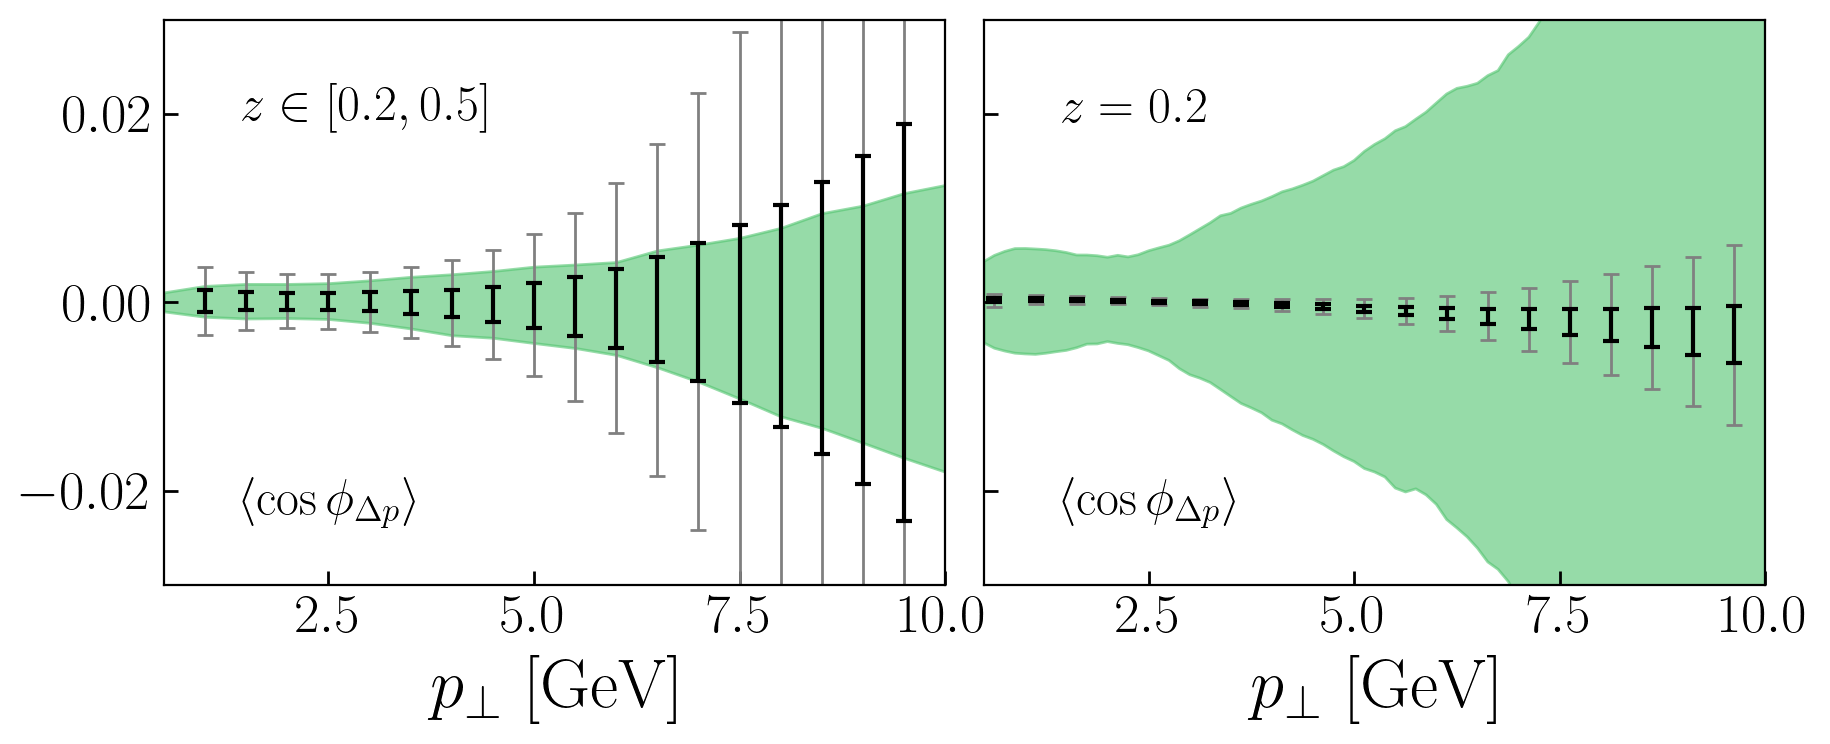

In [42]:
importlib.reload(tools)

# tools.plot_z_variation(zdata, target='p', 
#                        plot_bands=True, 
#                        errors_at_mean=True,
#                        save_plots=False
#                        )

# tools.plot_one_harmonic(tdata, target='p', 
#                      plot_bands=False,
#                      save_plots=True,
#                      errors_at_mean=True)

# tools.plot_target_variation(data, plot_bands=True, errors_at_mean=True)

tools.plot_t_variation(zdata, plot_bands=True, target='p', 
                       errors_at_mean=True, 
                       fname='dsa_z_binning.pdf',
                       save_plots=True)


# tools.plot_one_harmonic(data, plot_bands=True, errors_at_mean=True, save_plots=True, plot_mean=True)

# tools.plot_harmonics(data, plot_bands=True, smooth_plot=True, 
#                      labels = [r'DIS+SIDIS', r'+pp', r'+pp (constrained)'],
#                      plot_stat_errors=False,
#                      errors_at_mean=True, 
#                      save_plots=True,
#                      fname='dsa_fit_types.pdf',
#                      plot_mean=False)

# tools.plot_p_dist(mixdata, target='p', 
#                      ipT=5,
#                      save_plots=False,
#                      labels=[r'$pt$', r'$ptz$']
#                      )



(-5.0, 5.0)

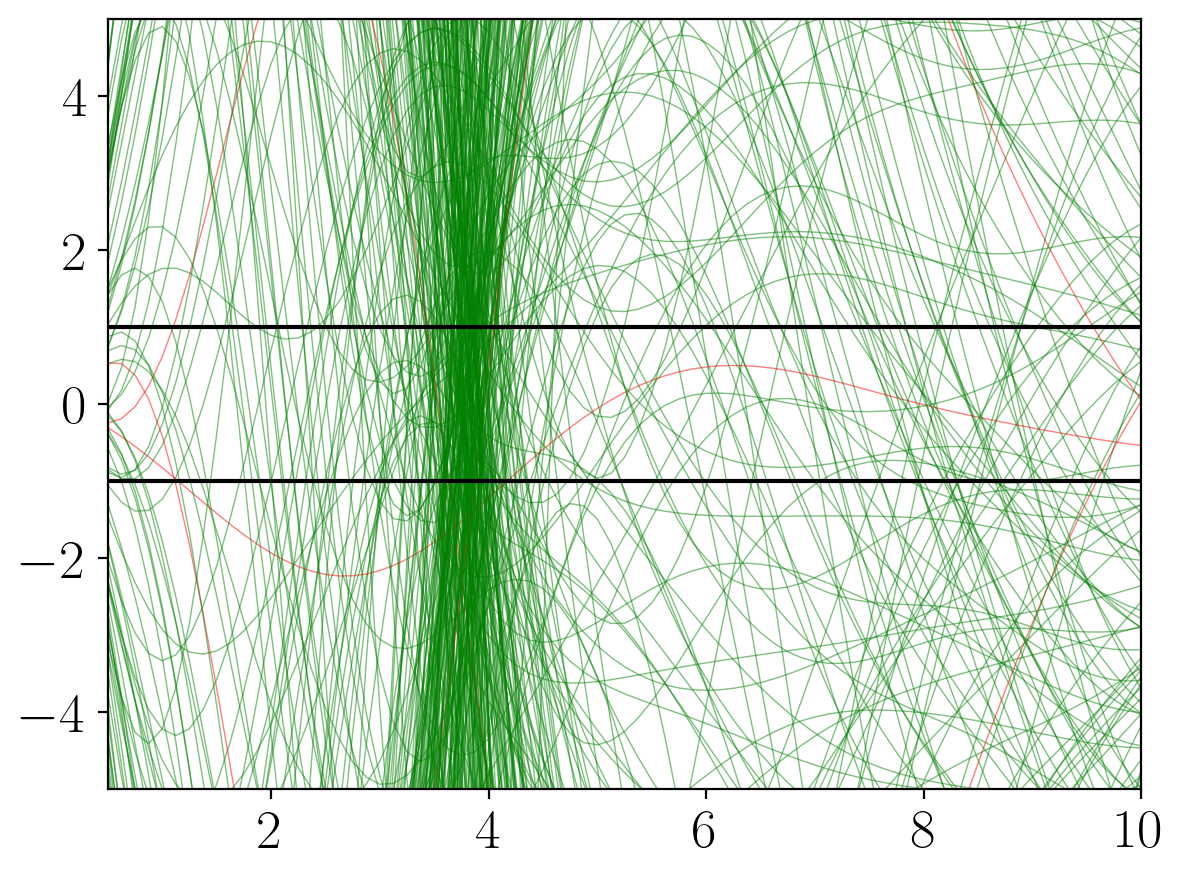

In [25]:
harm = '<cos(phi_kp)>'
tar  = 'p'
pT_values = zdata['data'][0]['pT values']
dpT = pT_values[1] - pT_values[0]
mean = zdata['bands'][0][tar]['mean'][harm]
stddev = zdata['errors'][0][tar]['corr']

slopes = []
for rep in zdata['data'][0][tar]:
    # slopes.append([(1/dpT)*(rep[harm][i+1]-rep[harm][i]) for i in range(len(rep[harm])-1)])
    slopes.append((rep[harm] - mean)/stddev)

asp_ratio = 4/3
psize = 5
nrows, ncols = 1,1
fig, ax = plt.subplots(nrows, ncols, figsize=(asp_ratio*psize*ncols, psize*nrows))

for slope in slopes:
    if np.abs(slope[-1]) < 1 and np.abs(slope[0]) < 1: color = 'red'
    else: color = 'green'
    ax.plot(pT_values, slope, color=color, alpha=0.5, linewidth=0.5)

ax.axhline(y=1, color='black')
ax.axhline(y=-1, color='black')

ax.set_ylim([-5,5])


